<a href="https://colab.research.google.com/github/znr6s28ynr-maker/Machine-Learning/blob/main/Rachel_Wiggins_CS_6600_Assignment_2_Pandas_and_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS-6600 Assignment 2 - Pandas and Matplotlib

*Weber State University*

**Rachel Wiggins**


For this assignment we're going to play around with some data visualizations. You'll also need to do a bit of data wrangling to get your data into the right format.

For this assignment, we'll download the popular "Baby Names" dataset from the Social Security Administration. You can find a description of this data [here](https://www.ssa.gov/oact/babynames/limits.html), and download the data as a csv file [here](https://www.kaggle.com/datasets/kaggle/us-baby-names). Please note **you do not need to download it**. You can access it directly from my (Dylan's) Google Drive using the code provided below.

The first thing we'll want to do is import our favorite libraries - Numpy, Pandas, and Matplotlib.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Now, let's read in the names data as a Pandas dataframe:

In [ ]:
url = 'https://drive.google.com/uc?export=download&id=1OLBPHdnJzmdhDTLR7AA5HVk_8RCaLpsj'
#This URL points to the NationalNames.csv file stored on my (Dylan's) Google Drive. You should all be able to access it.

In [ ]:
df_names = pd.read_csv(url) #Might take a few moments to download
df_names.head(5)

,Id,Name,Year,Gender,Count
0,1,Mary,1880,F,7065
1,2,Anna,1880,F,2604
2,3,Emma,1880,F,2003
3,4,Elizabeth,1880,F,1939
4,5,Minnie,1880,F,1746


The dataset contains names by year, gender, and count from 1880 until 2014. It's a pretty big file.

In [ ]:
df_names.shape

(1825433, 5)

Let's take a look at how the name "Dylan" has varied over time:

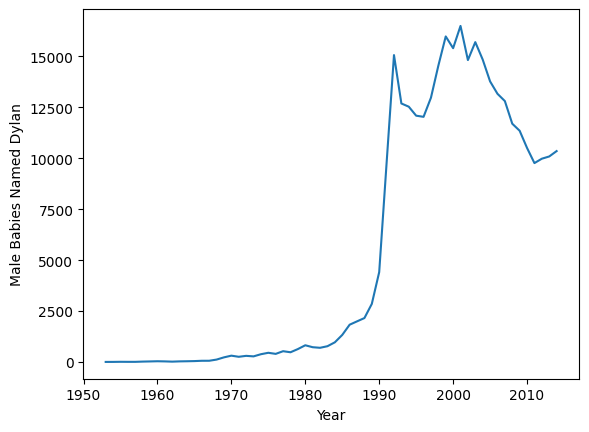

In [ ]:
df_dylan = df_names.loc[(df_names['Name'] == 'Dylan') & (df_names['Gender'] == 'M')]

fig, ax = plt.subplots()
ax.plot(df_dylan['Year'], df_dylan['Count'])

ax.set_xlabel('Year')
ax.set_ylabel('Male Babies Named Dylan')
plt.show()

Whoa! It seems like babies named Dylan only started appearing in the United States in the 1950s, and there was a huge increase starting around 1990. My best guess is [this](https://en.wikipedia.org/wiki/Beverly_Hills,_90210) is why.

Let's now take a look at the popularity of the name Patrick.

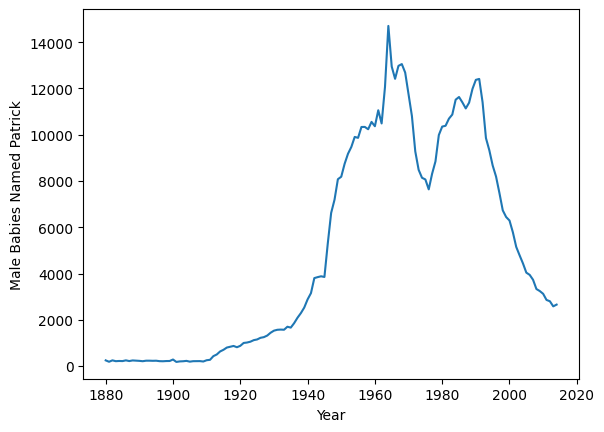

In [ ]:
df_patrick = df_names.loc[(df_names['Name'] == 'Patrick') & (df_names['Gender'] == 'M')]

fig, ax = plt.subplots()
ax.plot(df_patrick['Year'], df_patrick['Count'])

ax.set_xlabel('Year')
ax.set_ylabel('Male Babies Named Patrick')
plt.show()

It looks like we've got babies named Patrick as far back as the data goes, and there was a big spike in the 1940s that has come back down considerably since then.

For this assignment, you're going to explore the names data a bit more.

First, add another column in the df_names dataframe that provides the proportion of that name relative to all baby names that year for that gender. So, for example, a proportion of .1 for the name Mary in 1892 would mean that 10% of all female babies were named Mary that year.

In [ ]:
# TODO: Add a column 'prop' to the df_names dataframe containing the proportion information described above.

#aggregating values
df_name_totals = (
    df_names.groupby(['Year', 'Gender', 'Name'], as_index=False)['Count'].sum()
)

#total of babies by gender each year
yearly_totals = df_name_totals.groupby(['Year', 'Gender'])['Count'].transform('sum')

#figuring proportion
df_name_totals['Prop'] = df_name_totals['Count'] / yearly_totals

df_name_totals.head(5)


,Year,Gender,Name,Count,Prop
0,1880,F,Abbie,71,0.000780
1,1880,F,Abby,6,0.000066
2,1880,F,Abigail,12,0.000132
3,1880,F,Ada,652,0.007165
4,1880,F,Adah,24,0.000264


Next, like the spike we saw with "Dylan" around 1990, there are other names associated with, for example, popular movie or TV characters that we might expect to see increase significantly when those characters become popular. You should create a line plot that contains:

* The proportion over time of four names that you'd expect to increase in popularity significantly around a particular event like a popular Disney movie.
* A legend indicating what these four names are.
* Annotations pointing out these increases and providing a quick description as to why. For example "Aladdin Released" might be the annotation that indicates why the name "Jasmine" became much more popular.

Use different colors for the different names, and label the axes of the figure accordingly.

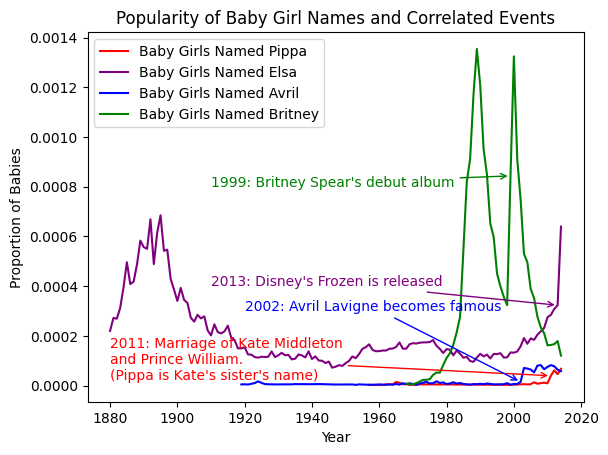

In [ ]:
#TODO: Draw the line plots described above.

#getting data on 4 names
df_pippa_prop = df_name_totals[(df_name_totals['Name'] == 'Pippa') & (df_name_totals['Gender'] == 'F')]
df_elsa_prop = df_name_totals[(df_name_totals['Name'] == 'Elsa') & (df_name_totals['Gender'] == 'F')]
df_avril_prop = df_name_totals[(df_name_totals['Name'] == 'Avril') & (df_name_totals['Gender'] == 'F')]
df_britney_prop = df_name_totals[(df_name_totals['Name'] == 'Britney') & (df_name_totals['Gender'] == 'F')]

fig, ax = plt.subplots()

#plotting proportion by year
ax.plot(
    df_pippa_prop['Year'],
    df_pippa_prop['Prop'],
    label='Baby Girls Named Pippa',
    color='red'
)

ax.plot(
    df_elsa_prop['Year'],
    df_elsa_prop['Prop'],
    label='Baby Girls Named Elsa',
    color='purple'
)

ax.plot(
    df_avril_prop['Year'],
    df_avril_prop['Prop'],
    label='Baby Girls Named Avril',
    color='blue'
)

ax.plot(
    df_britney_prop['Year'],
    df_britney_prop['Prop'],
    label='Baby Girls Named Britney',
    color='green'
)

#getting proportion at time of name event
pippa_2011 = df_pippa_prop.loc[
    df_pippa_prop['Year'] == 2011, 'Prop'
].iloc[0]

elsa_2013 = df_elsa_prop.loc[
    df_elsa_prop['Year'] == 2013, 'Prop'
].iloc[0]

avril_2002 = df_avril_prop.loc[
    df_avril_prop['Year'] == 2002, 'Prop'
].iloc[0]

britney_1999 = df_britney_prop.loc[
    df_britney_prop['Year'] == 1999, 'Prop'
].iloc[0]

#labels
ax.annotate(
    "2011: Marriage of Kate Middleton\n"
    "and Prince William.\n"
    "(Pippa is Kate's sister's name)",
    xy=(2011, pippa_2011),
    xytext=(1880, 2.3e-5),
    color='red',
    arrowprops=dict(
        arrowstyle='->',
        color='red'
    )
)

ax.annotate(
    "2013: Disney's Frozen is released",
    xy=(2013, elsa_2013),
    xytext=(1910, 4e-4),
    color='purple',
    arrowprops=dict(
        arrowstyle='->',
        color='purple'
    )
)

ax.annotate(
    "2002: Avril Lavigne becomes famous",
    xy=(2002, avril_2002),
    xytext=(1920, 3e-4),
    color='blue',
    arrowprops=dict(
        arrowstyle='->',
        color='blue'
    )
)

ax.annotate(
    "1999: Britney Spear's debut album",
    xy=(1999, britney_1999),
    xytext=(1910, 8e-4),
    color='green',
    arrowprops=dict(
        arrowstyle='->',
        color='green'
    )
)

#graph information
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Babies')
plt.title('Popularity of Baby Girl Names and Correlated Events')
plt.legend()
plt.show()


Finally, we're going to investigate whether the most popular men's names tend to be more dominant than the most popular women's names, or vice-versa.

To do this, first create a new dataframe that contains the 10 most popular names each decade by proportion. Here proportion means the percentage of babies born that decade of the given gender with that name. The rows of this dataframe should be:
* Indexed by decade (1880, 1890, 1900, etc...)
* Three columns: Name, Gender, Proportion

Using this dataframe, create a scatterplot where each row is a mark and:

* The horizontal axis represents decade.
* The vertical axis represents proportion.
* The marks are colored to indicate gender.

Provide appropriate titles and legends to make this plot clear. Does it look like the most popular male names tend to be more dominant?

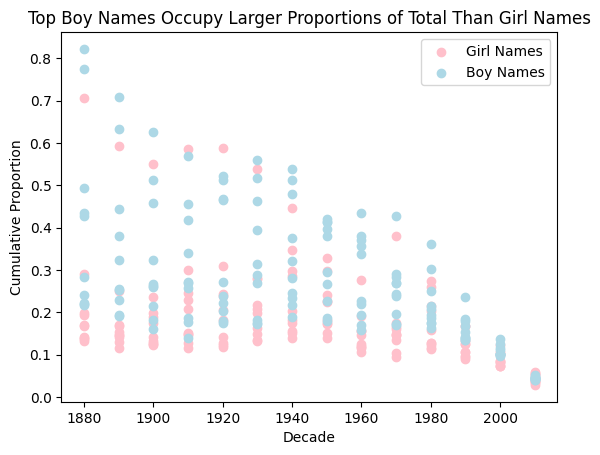

In [ ]:
# TODO: Create the figure described above.

#creating decade_names database
decade_names = df_name_totals[['Name', 'Gender', 'Prop']].copy()

def decade(year):
    decade = year - (year % 10)
    return decade

decade_names['Decade'] = df_name_totals['Year'].apply(decade)

decade_names = decade_names.reindex(columns=['Decade', 'Name', 'Gender', "Prop"])

decade_names = decade_names.set_index('Decade')


#aggregating values
decade_name_props = (
    decade_names.groupby(['Decade', 'Gender', 'Name'])
    ['Prop'].sum().reset_index()
)

#sorting most to least popular by decade and gender
decade_name_props = decade_name_props.sort_values(
    ['Decade', 'Gender', 'Prop'],
    ascending=[True, True, False]
)

#taking top 10 in each group
top_10_names = (
    decade_name_props.groupby(['Decade', 'Gender'])
    .head(10)
    .copy()
)

#separating gender
girl_names = top_10_names[
    top_10_names['Gender'] == 'F'
]

boy_names = top_10_names[
    top_10_names['Gender'] == 'M'
]

#plotting values
fig, ax = plt.subplots()

ax.scatter(
    girl_names['Decade'],
    girl_names['Prop'],
    color='pink',
    label='Girl Names'
)

ax.scatter(
    boy_names['Decade'],
    boy_names['Prop'],
    color='lightblue',
    label='Boy Names'
)

ax.set_xlabel('Decade')
ax.set_ylabel('Cumulative Proportion')

plt.title("Top Boy Names Occupy Larger Proportions of Total Than Girl Names")
plt.legend()
plt.show()

It looks like the male names do tend to be more dominant! I am curious if this means that there are fewer boys names in use at any one time than girl names, so the top boy names occupy larger proportions than girl names.

When this is done, please upload your completed notebook to Canvas for grading. Thank you!